## iSnobal workflow
Modified from Joe Meyer

In [1]:
import numpy as np
import math as m
from datetime import datetime

from netCDF4 import Dataset

from snobedo.input import HrrrParameter, SmrfTopo
from snobedo.shortwave import TopoShade

import matplotlib.pyplot as plt

## Declare variables to find data 

In [2]:
UVU_OLSON_HOME = '/uufs/chpc.utah.edu/common/home/uvu-group1/olson/snow-data/'
HRRR_DATA = UVU_OLSON_HOME + 'HRRR/'
ERW_TOPO_FILE = UVU_OLSON_HOME + 'isnobal-data/ERW_topo.nc'

## Access the sky-view factors from topo

In [3]:
with Dataset(ERW_TOPO_FILE) as dem:
    sky_view_factor = dem['sky_view_factor'][:].astype(np.float64)

In [4]:
sky_view_factor

masked_array(
  data=[[0.90764373, 0.90160327, 0.87204783, ..., 0.96763542, 0.97887733,
         0.98330146],
        [0.87995018, 0.86740591, 0.81930077, ..., 0.97601105, 0.98206188,
         0.98354592],
        [0.83752437, 0.8177492 , 0.77636379, ..., 0.97050725, 0.97584268,
         0.97335441],
        ...,
        [0.87855814, 0.89022444, 0.8855338 , ..., 0.95064361, 0.95388958,
         0.93882772],
        [0.90449759, 0.86569677, 0.84933238, ..., 0.95202325, 0.94747276,
         0.92465977],
        [0.890127  , 0.82381173, 0.78123565, ..., 0.9661788 , 0.94509181,
         0.91614504]],
  mask=False,
  fill_value=1e+20)

## Calculate illumination angle for given date range

This uses the center X and Y of the topo and the mean elevation to calculate the sun position.

### Create a object that can calculate shade based on a topo file 

Here the underlying library for the sun position:  
https://github.com/skyfielders/python-skyfield/

In [5]:
topo_solar = TopoShade(
    ERW_TOPO_FILE, TopoShade.SolarMethods.SKYFIELD
)

### Create a 24 hour time range 

In [6]:
time_range = np.arange(
        '2023-03-01',
        '2023-03-02',
        np.timedelta64(1, 'h'),
        dtype='datetime64[s]'
    )

In [7]:
time_range

array(['2023-03-01T00:00:00', '2023-03-01T01:00:00',
       '2023-03-01T02:00:00', '2023-03-01T03:00:00',
       '2023-03-01T04:00:00', '2023-03-01T05:00:00',
       '2023-03-01T06:00:00', '2023-03-01T07:00:00',
       '2023-03-01T08:00:00', '2023-03-01T09:00:00',
       '2023-03-01T10:00:00', '2023-03-01T11:00:00',
       '2023-03-01T12:00:00', '2023-03-01T13:00:00',
       '2023-03-01T14:00:00', '2023-03-01T15:00:00',
       '2023-03-01T16:00:00', '2023-03-01T17:00:00',
       '2023-03-01T18:00:00', '2023-03-01T19:00:00',
       '2023-03-01T20:00:00', '2023-03-01T21:00:00',
       '2023-03-01T22:00:00', '2023-03-01T23:00:00'],
      dtype='datetime64[s]')

### Convert the time to Python datetime objects 

In [8]:
time_range = [datetime.fromisoformat(str(r)) for r in time_range]

### Calculate the shade for the target time range

In [9]:
topo_solar.calculate(time_range)

### Access the information
#### All Azimuth

In [10]:
topo_solar.azimuth

{datetime.datetime(2023, 3, 1, 7, 0, tzinfo=<UTC>): -181,
 datetime.datetime(2023, 3, 1, 8, 0, tzinfo=<UTC>): -181,
 datetime.datetime(2023, 3, 1, 9, 0, tzinfo=<UTC>): -181,
 datetime.datetime(2023, 3, 1, 10, 0, tzinfo=<UTC>): -181,
 datetime.datetime(2023, 3, 1, 11, 0, tzinfo=<UTC>): -181,
 datetime.datetime(2023, 3, 1, 12, 0, tzinfo=<UTC>): -181,
 datetime.datetime(2023, 3, 1, 13, 0, tzinfo=<UTC>): 79.42805823479617,
 datetime.datetime(2023, 3, 1, 14, 0, tzinfo=<UTC>): 72.99245214049738,
 datetime.datetime(2023, 3, 1, 15, 0, tzinfo=<UTC>): 62.44823593245019,
 datetime.datetime(2023, 3, 1, 16, 0, tzinfo=<UTC>): 50.07785102348106,
 datetime.datetime(2023, 3, 1, 17, 0, tzinfo=<UTC>): 35.013390546075215,
 datetime.datetime(2023, 3, 1, 18, 0, tzinfo=<UTC>): 16.840842000752815,
 datetime.datetime(2023, 3, 1, 19, 0, tzinfo=<UTC>): -3.428955972344795,
 datetime.datetime(2023, 3, 1, 20, 0, tzinfo=<UTC>): -23.244182156382777,
 datetime.datetime(2023, 3, 1, 21, 0, tzinfo=<UTC>): -40.42796365366

#### All Zenith 

In [11]:
topo_solar.zenith

{datetime.datetime(2023, 3, 1, 7, 0, tzinfo=<UTC>): 0,
 datetime.datetime(2023, 3, 1, 8, 0, tzinfo=<UTC>): 0,
 datetime.datetime(2023, 3, 1, 9, 0, tzinfo=<UTC>): 0,
 datetime.datetime(2023, 3, 1, 10, 0, tzinfo=<UTC>): 0,
 datetime.datetime(2023, 3, 1, 11, 0, tzinfo=<UTC>): 0,
 datetime.datetime(2023, 3, 1, 12, 0, tzinfo=<UTC>): 0,
 datetime.datetime(2023, 3, 1, 13, 0, tzinfo=<UTC>): 88.96298019091023,
 datetime.datetime(2023, 3, 1, 14, 0, tzinfo=<UTC>): 81.39761675522543,
 datetime.datetime(2023, 3, 1, 15, 0, tzinfo=<UTC>): 70.58579014545766,
 datetime.datetime(2023, 3, 1, 16, 0, tzinfo=<UTC>): 60.858796866575794,
 datetime.datetime(2023, 3, 1, 17, 0, tzinfo=<UTC>): 52.93263046791036,
 datetime.datetime(2023, 3, 1, 18, 0, tzinfo=<UTC>): 47.78771082838127,
 datetime.datetime(2023, 3, 1, 19, 0, tzinfo=<UTC>): 46.39868350905041,
 datetime.datetime(2023, 3, 1, 20, 0, tzinfo=<UTC>): 49.093918620050566,
 datetime.datetime(2023, 3, 1, 21, 0, tzinfo=<UTC>): 55.26262765448131,
 datetime.datetim

#### Illimuation Angles

In [12]:
topo_solar.illumination_angles

{datetime.datetime(2023, 3, 1, 7, 0, tzinfo=<UTC>): 0,
 datetime.datetime(2023, 3, 1, 8, 0, tzinfo=<UTC>): 0,
 datetime.datetime(2023, 3, 1, 9, 0, tzinfo=<UTC>): 0,
 datetime.datetime(2023, 3, 1, 10, 0, tzinfo=<UTC>): 0,
 datetime.datetime(2023, 3, 1, 11, 0, tzinfo=<UTC>): 0,
 datetime.datetime(2023, 3, 1, 12, 0, tzinfo=<UTC>): 0,
 datetime.datetime(2023, 3, 1, 13, 0, tzinfo=<UTC>): array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.40819051, 0.33067496, 0.1846043 , ..., 0.        , 0.        ,
         0.        ],
        [0.21538423, 0.10028871, 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]]),
 datetime.datetime(2023,

### Convert the dictionaries with datetime object keys to accessible strings

Times are UTC  
Each value is an array of the topo with a value per pixel

In [13]:
illumination_angles = { key.strftime('%Y-%m-%d %H:%M'): value for key, value in topo_solar.illumination_angles.items() }

In [14]:
illumination_angles

{'2023-03-01 07:00': 0,
 '2023-03-01 08:00': 0,
 '2023-03-01 09:00': 0,
 '2023-03-01 10:00': 0,
 '2023-03-01 11:00': 0,
 '2023-03-01 12:00': 0,
 '2023-03-01 13:00': array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.40819051, 0.33067496, 0.1846043 , ..., 0.        , 0.        ,
         0.        ],
        [0.21538423, 0.10028871, 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]]),
 '2023-03-01 14:00': array([[0.        , 0.        , 0.        , ..., 0.01893361, 0.0816876 ,
         0.12431614],
        [0.        , 0.        , 0.        , ..., 0.02335223, 0.0810594 ,
         0.11728871],
        [0.        , 0.        , 

### Access sunrise 

In [15]:
illumination_angles['2023-03-01 13:00']

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.40819051, 0.33067496, 0.1846043 , ..., 0.        , 0.        ,
        0.        ],
       [0.21538423, 0.10028871, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

## Read a given HRRR hour shortwave variable

In [16]:
# Set the PROJ_LIB environment variable
# Annoying Jupter bug
import os
os.environ['PROJ_LIB'] = '/uufs/chpc.utah.edu/common/home/skiles-group1/jmeyer/conda/envs/smeshr/share/proj' 

In [17]:
# hrrr_dswrf = HrrrParameter(ERW_TOPO_FILE, HRRR_DATA + 'hrrr.20230301/hrrr.t00z.wrfsfcf06.grib2', 'bilinear')
time_utc = 19
hrrr_dswrf = HrrrParameter(ERW_TOPO_FILE, HRRR_DATA + f'hrrr.20230302/hrrr.t{time_utc-6}z.wrfsfcf06.grib2', 'bilinear')

### Explore the bands

In [18]:
hrrr_dswrf.grib_metadata(hrrr_dswrf.grib_file, 1)

{'GRIB_COMMENT': 'Geopotential height [gpm]',
 'GRIB_DISCIPLINE': '0(Meteorological)',
 'GRIB_ELEMENT': 'HGT',
 'GRIB_FORECAST_SECONDS': '21600',
 'GRIB_IDS': 'CENTER=7(US-NCEP) SUBCENTER=0 MASTER_TABLE=2 LOCAL_TABLE=1 SIGNF_REF_TIME=1(Start_of_Forecast) REF_TIME=2023-03-02T13:00:00Z PROD_STATUS=0(Operational) TYPE=1(Forecast)',
 'GRIB_PDS_PDTN': '0',
 'GRIB_PDS_TEMPLATE_ASSEMBLED_VALUES': '3 5 2 0 83 0 0 1 6 1 0 0 255 0 0',
 'GRIB_PDS_TEMPLATE_NUMBERS': '3 5 2 0 83 0 0 0 1 0 0 0 6 1 0 0 0 0 0 255 0 0 0 0 0',
 'GRIB_REF_TIME': '1677762000',
 'GRIB_SHORT_NAME': '0-SFC',
 'GRIB_UNIT': '[gpm]',
 'GRIB_VALID_TIME': '1677783600'}

### Shortwave is usually band number 10

In [19]:
hrrr_dswrf.grib_metadata(hrrr_dswrf.grib_file, 10)

{'GRIB_COMMENT': 'Downward short-wave radiation flux [W/(m^2)]',
 'GRIB_DISCIPLINE': '0(Meteorological)',
 'GRIB_ELEMENT': 'DSWRF',
 'GRIB_FORECAST_SECONDS': '21600',
 'GRIB_IDS': 'CENTER=7(US-NCEP) SUBCENTER=0 MASTER_TABLE=2 LOCAL_TABLE=1 SIGNF_REF_TIME=1(Start_of_Forecast) REF_TIME=2023-03-02T13:00:00Z PROD_STATUS=0(Operational) TYPE=1(Forecast)',
 'GRIB_PDS_PDTN': '0',
 'GRIB_PDS_TEMPLATE_ASSEMBLED_VALUES': '4 7 2 0 83 0 0 1 6 1 0 0 255 0 0',
 'GRIB_PDS_TEMPLATE_NUMBERS': '4 7 2 0 83 0 0 0 1 0 0 0 6 1 0 0 0 0 0 255 0 0 0 0 0',
 'GRIB_REF_TIME': '1677762000',
 'GRIB_SHORT_NAME': '0-SFC',
 'GRIB_UNIT': '[W/(m^2)]',
 'GRIB_VALID_TIME': '1677783600'}

### Get the forecasted hour of a band

In [20]:
hrrr_dswrf.timestep_for_band(10)

datetime.datetime(2023, 3, 2, 19, 0, tzinfo=datetime.timezone.utc)

In [21]:
str(hrrr_dswrf.timestep_for_band(10))

'2023-03-02 19:00:00+00:00'

### The reprojected and interpolated data as an array

In [22]:
dswrf_data = hrrr_dswrf.grib_file.GetRasterBand(10).ReadAsArray()

In [23]:
dswrf_data

array([[605.79730921, 606.56627959, 607.3383774 , ..., 652.23470924,
        653.68729297, 655.14318284],
       [605.35635424, 606.14450055, 606.93577428, ..., 652.27089301,
        653.74375115, 655.21991543],
       [604.91224059, 605.71956281, 606.53001247, ..., 652.30373534,
        653.79686788, 655.29330657],
       ...,
       [732.43577303, 733.52008454, 734.60967895, ..., 634.34155239,
        634.76170859, 635.19032638],
       [731.8016093 , 732.9182443 , 734.04016221, ..., 633.77710772,
        634.24904338, 634.72944065],
       [731.16210838, 732.31106686, 733.46530827, ..., 633.20411278,
        633.72782789, 634.26000464]])

### The shape of the array matches the illumination angles

In [24]:
dswrf_data.shape

(837, 656)

In [25]:
sky_view_factor.shape

(837, 656)

## Visualization

In [26]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [28]:
# swmod_down = dswrf_data * illumination_angles['2023-03-01 16:00'] * sky_view_factor 
utc_string = str(hrrr_dswrf.timestep_for_band(10)).split(':', 2)
swmod_down = dswrf_data * illumination_angles[":".join(utc_string[:2])] * sky_view_factor 

# Determine the color limits (vmin and vmax) based on both datasets
# vmin = min(swmod_down.min(), sw_in_smrf.min())
# vmax = max(swmod_down.max(), sw_in_smrf.max())

# Create subplots
fig, axs = plt.subplots(1, 3, figsize=(10, 5))

# Plot raster data and store the returned image object
im1 = axs[0].imshow(sky_view_factor, cmap='grey')
axs[0].set_title('Skyview Factor')

im2 = axs[1].imshow(illumination_angles['2023-03-02 19:00'], cmap='grey')
axs[1].set_title('Illumination angle')
axs[1].get_yaxis().set_visible(False) # axs[1].axis('off')

im3 = axs[2].imshow(swmod_down, cmap='viridis')
axs[2].set_title('SMRF Model output')
axs[2].get_yaxis().set_visible(False)

# colorbar size
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im1, ax=axs[0], cax=cax)
#
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im2, ax=axs[1], cax=cax)
#
divider = make_axes_locatable(axs[2])
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im3, ax=axs[2], cax=cax)

# Add colorbars
# fig.colorbar(im1, ax=axs[0])  # Colorbar for the first subplot
# fig.colorbar(im2, ax=axs[1])  # Colorbar for the second subplot
# fig.colorbar(im3, ax=axs[2])

plt.show()

KeyError: '2023-03-02 19:00'

In [ ]:
# m.ceil(len(sub_illum.keys())/4)
# len(sub_illum.keys())

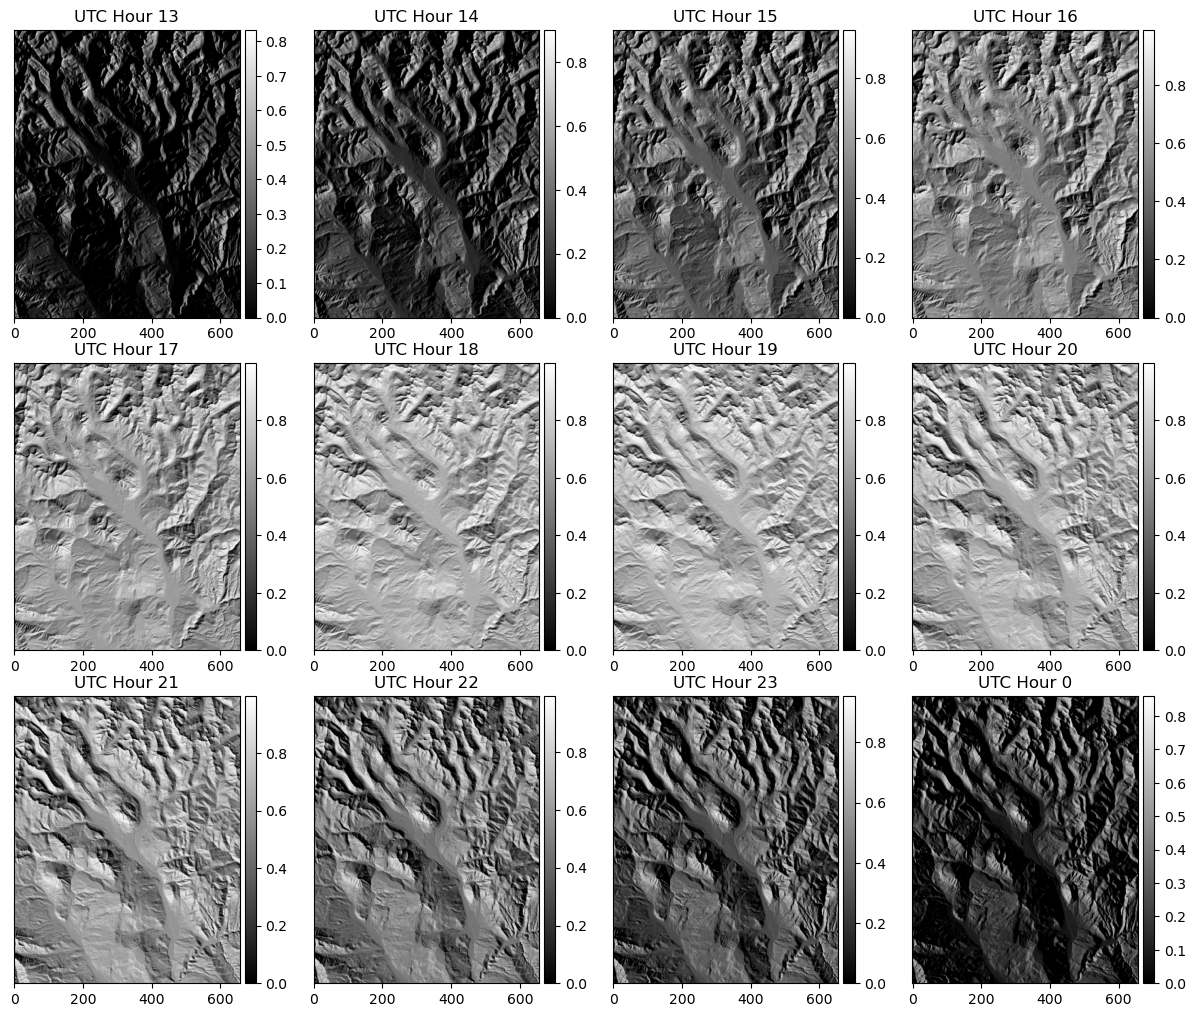

In [29]:
# Plot daily

# Subset illumination angles for daylight hours
sub_desc = {key: value for key, value in topo_solar.zenith.items() if value != 0}
sub_illum = {k: topo_solar.illumination_angles[k] for k in sub_desc.keys()}

# subset by location (add 1 hr before and after)
ind = [i for i, val in enumerate(topo_solar.zenith.values()) if val != 0]
# i_subset = dict(list(topo_solar.zenith.items())[min(ind)-1:max(ind)+2])
# sub_illum = dict(list(topo_solar.illumination_angles.items())[min(ind)-1:max(ind)+2])

# plot dimensions
# nrow_plot = len(sub_desc.keys())/4
nrow_plot = m.ceil(len(sub_illum.keys())/4) #m.ceil(len(sub_desc.keys())/4)

# MULLTI-plot
fig, axes = plt.subplots(nrow_plot, 4, figsize=(12, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# dimentions based on hours in day
# Loop through the image data and plot each image in a subplot
for i, illum_time in enumerate(sub_illum):
    # forecast hour
    if illum_time.hour < next(iter(sub_illum)).hour:
        hrrr_fhr = 24 + illum_time.hour - 6
    else:
        hrrr_fhr = illum_time.hour - 6
    if hrrr_fhr < 10:
        hrrr_fhr = str("0" + str(hrrr_fhr))
        
    # read in HRRR timestamp
    hrrr_dswrf = HrrrParameter(ERW_TOPO_FILE, HRRR_DATA + f'hrrr.20230301/hrrr.t{hrrr_fhr}z.wrfsfcf06.grib2', 'bilinear')
    dswrf_data = hrrr_dswrf.grib_file.GetRasterBand(10).ReadAsArray()
    
    # illumination for HRRR timestamp
    utc_string = str(illum_time).split(':', 2)
    illum_hr = illumination_angles[":".join(utc_string[:2])]
    # account for scalars
    if not hasattr(illum_hr, "__len__"):
        illum_hr = np.zeros_like(sky_view_factor)
        
    swmod_down = dswrf_data * illum_hr * sky_view_factor 

    # set plot
    ax = axes[i]
    # ax.imshow(swmod_down, cmap='viridis')
    im = ax.imshow(illum_hr, cmap='gray')  
    ax.set_title(f'UTC Hour {illum_time.hour}') 
    # ax.axis('off')
    ax.get_yaxis().set_visible(False)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, ax=ax, cax=cax)

# fig.colorbar(im1, ax=axs[0])
plt.tight_layout(pad=0.1)

# Show the plot with all images
plt.show()

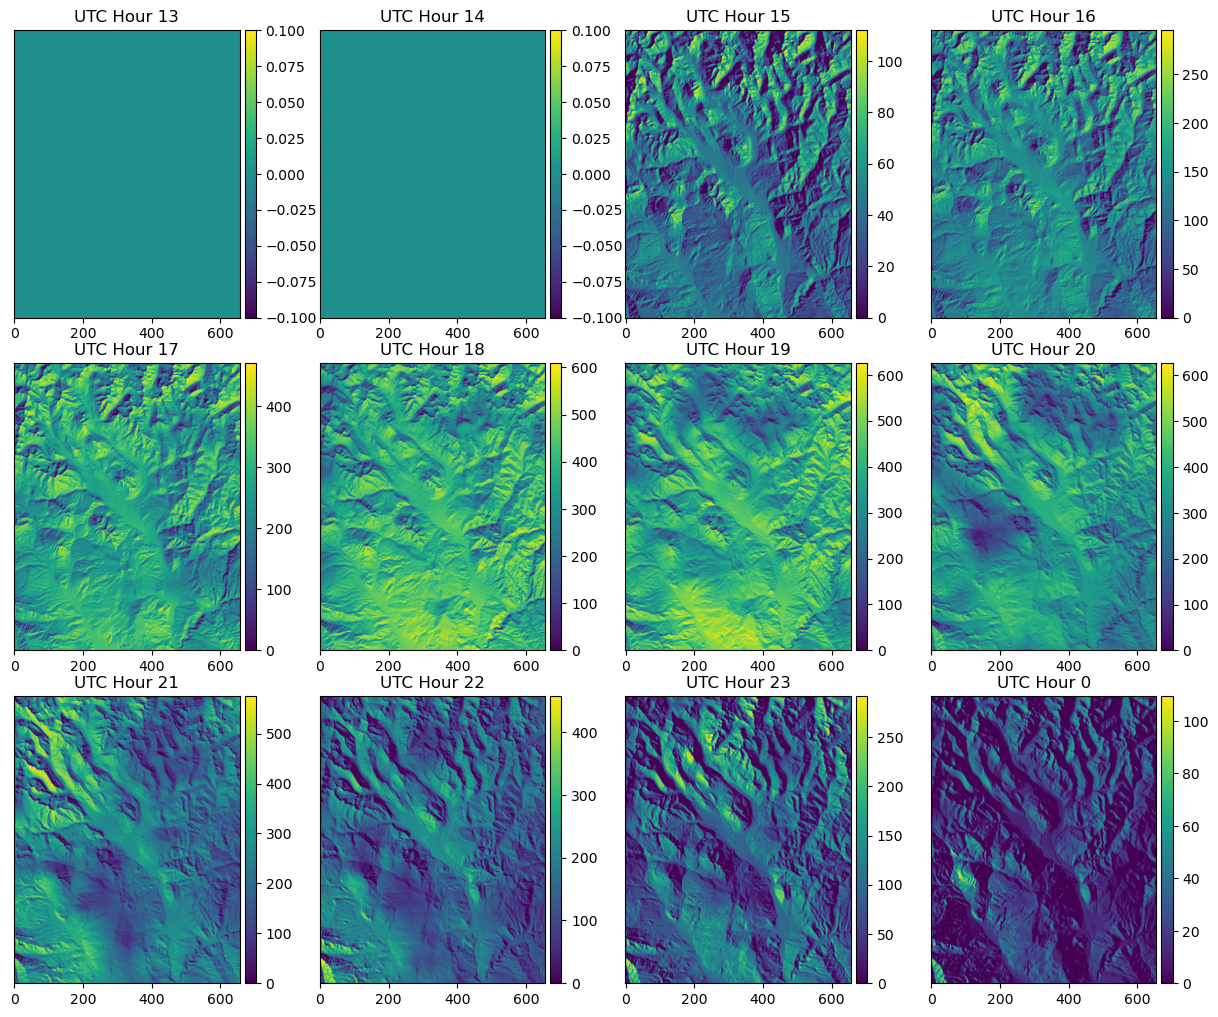

In [30]:
# MULLTI-plot
# Create subplots
fig, axes = plt.subplots(nrow_plot, 4, figsize=(12, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# 3 x 3 = 9 hrs
# Loop through the image data and plot each image in a subplot
for i, illum_time in enumerate(sub_illum):
    # forecast hour
    if illum_time.hour < next(iter(sub_illum)).hour:
        hrrr_fhr = 24 + illum_time.hour - 6
    else:
        hrrr_fhr = illum_time.hour - 6
    if hrrr_fhr < 10:
        hrrr_fhr = str("0" + str(hrrr_fhr))

    image_path = HRRR_DATA + f'hrrr.20230301/hrrr.t{hrrr_fhr}z.wrfsfcf06.grib2'
    # print(image_path)
    
    # read in HRRR timestamp
    hrrr_dswrf = HrrrParameter(ERW_TOPO_FILE, image_path, 'bilinear')
    dswrf_data = hrrr_dswrf.grib_file.GetRasterBand(10).ReadAsArray()
    
    # illumination for HRRR timestamp
    utc_string = str(illum_time).split(':', 2)
    illum_hr = illumination_angles[":".join(utc_string[:2])]
        
    swmod_down = dswrf_data * illum_hr * sky_view_factor 

    # set plot
    ax = axes[i]
    im = ax.imshow(swmod_down, cmap='viridis')
    # ax.imshow(illum_hr, cmap='gray')  
    ax.set_title(f'UTC Hour {illum_time.hour}') 
    # ax.axis('off')
    ax.get_yaxis().set_visible(False)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, ax=ax, cax=cax)

# fig.colorbar(im1, ax=ax[6])
plt.tight_layout(pad=0.1)

# Show the plot with all images
plt.show()

## Need to adjust HRRR hour by -1 to account for start of hour forecast?

Ask Joe and look into details

In [31]:
sky_view_factor.shape
m.cos(90*m.pi/180)

6.123233995736766e-17

In [32]:
# additional 0 values at start of HRRR day

# check darkness hours in illumination
sub_illum2 = dict(list(topo_solar.illumination_angles.items())[min(ind)-1:max(ind)+2])
for i, illum_time in enumerate(sub_illum2):
    
    utc_string = str(illum_time).split(':', 2)
    illum_hr = illumination_angles[":".join(utc_string[:2])] 
    if hasattr(illum_hr, "__len__"):
        print(illum_hr.shape)
    else:
        print(str(i) + " - dark - ", illum_hr)


0 - dark -  0
(837, 656)
(837, 656)
(837, 656)
(837, 656)
(837, 656)
(837, 656)
(837, 656)
(837, 656)
(837, 656)
(837, 656)
(837, 656)
(837, 656)
13 - dark -  0


In [33]:
isinstance(type(next(iter(sub_illum2.values()))), np.ndarray)

False

In [34]:
hasattr(next(iter(sub_illum.values())), "__len__")

True

In [35]:
print(":".join(utc_string[:2]))
zenith_angles = { key.strftime('%Y-%m-%d %H:%M'): value for key, value in topo_solar.zenith.items() }
zenith_angles["2023-03-02 01:00"]
zenith_angles[":".join(utc_string[:2])]

2023-03-02 01:00


0

In [36]:
len(np.array(list(topo_solar.zenith.keys())))
zenith_angles.values()

dict_values([0, 0, 0, 0, 0, 0, 88.96298019091023, 81.39761675522543, 70.58579014545766, 60.858796866575794, 52.93263046791036, 47.78771082838127, 46.39868350905041, 49.093918620050566, 55.26262765448131, 63.86906892443774, 74.00960797584196, 85.05339862984526, 0, 0, 0, 0, 0, 0])

In [37]:
zen2 = {key : 90 if val == 0 or val == 90 else val for key, val in zenith_angles.items()}
np.cos( np.array(list(zen2.values())) * m.pi/180 )

array([6.12323400e-17, 6.12323400e-17, 6.12323400e-17, 6.12323400e-17,
       6.12323400e-17, 6.12323400e-17, 1.80984219e-02, 1.49576471e-01,
       3.32395049e-01, 4.86963611e-01, 6.02753659e-01, 6.71879466e-01,
       6.89636183e-01, 6.54821036e-01, 5.69815663e-01, 4.40423905e-01,
       2.75476157e-01, 8.62272696e-02, 6.12323400e-17, 6.12323400e-17,
       6.12323400e-17, 6.12323400e-17, 6.12323400e-17, 6.12323400e-17])

In [38]:
# del zen2[False]
zen2
np.array(list(zenith_angles.values()))[:-1]

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , 88.96298019, 81.39761676, 70.58579015, 60.85879687,
       52.93263047, 47.78771083, 46.39868351, 49.09391862, 55.26262765,
       63.86906892, 74.00960798, 85.05339863,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ])

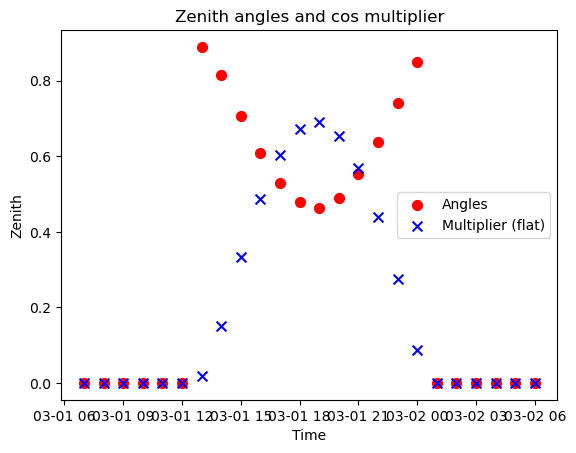

In [39]:
time = np.array(list(topo_solar.zenith.keys()))
zen_ang = np.array(list(zenith_angles.values())) / 100
zenith_mult = np.cos( np.array(list(zen2.values())) * m.pi/180 )

# plt.scatter(time, zen_ang[:-1], s=50, c='red', marker='o', label='Angles')
# plt.scatter(time, zenith_mult[:-1], s=50, c='blue', marker='x', label='Multiplier (flat)')

plt.scatter(time, zen_ang, s=50, c='red', marker='o', label='Angles')
plt.scatter(time, zenith_mult, s=50, c='blue', marker='x', label='Multiplier (flat)')
plt.xlabel("Time")
plt.ylabel("Zenith")
plt.title("Zenith angles and cos multiplier")
plt.legend()
plt.show()

In [40]:
len(time)
len(zenith_mult)

24

## Model - simple (no shade)

In [41]:
zenith_angles = { key.strftime('%Y-%m-%d %H:%M'): value for key, value in topo_solar.zenith.items() }

['2023-03-01 12', '00', '00+00:00']
['2023-03-01 13', '00', '00+00:00']
['2023-03-01 14', '00', '00+00:00']
['2023-03-01 15', '00', '00+00:00']
['2023-03-01 16', '00', '00+00:00']
['2023-03-01 17', '00', '00+00:00']
['2023-03-01 18', '00', '00+00:00']
['2023-03-01 19', '00', '00+00:00']
['2023-03-01 20', '00', '00+00:00']
['2023-03-01 21', '00', '00+00:00']
['2023-03-01 22', '00', '00+00:00']
['2023-03-01 23', '00', '00+00:00']
['2023-03-02 00', '00', '00+00:00']
['2023-03-02 01', '00', '00+00:00']


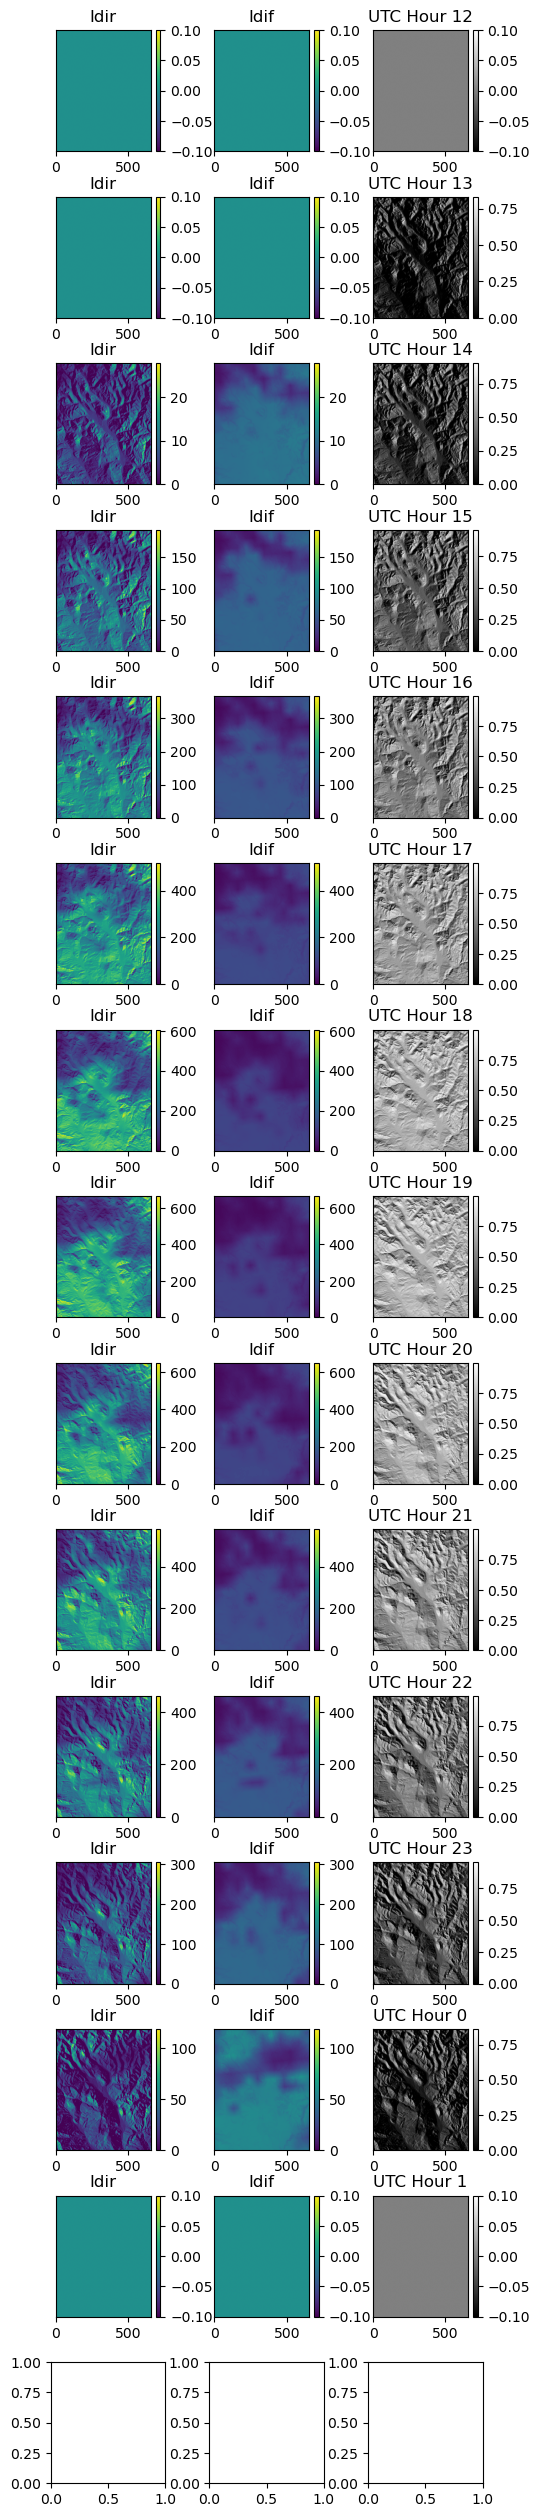

In [48]:
# Subset illumination angles for daylight hours
sub_desc = {key: value for key, value in topo_solar.zenith.items() if value != 0}
sub_illum = {k: topo_solar.illumination_angles[k] for k in sub_desc.keys()}

# subset by location (add 1 hr before and after)
ind = [i for i, val in enumerate(topo_solar.zenith.values()) if val != 0]
# i_subset = dict(list(topo_solar.zenith.items())[min(ind)-1:max(ind)+2])
sub_illum = dict(list(topo_solar.illumination_angles.items())[min(ind)-1:max(ind)+2])

# plot dimensions
# nrow_plot = len(sub_desc.keys())/4
nrow_plot = m.ceil(len(sub_illum.keys())/3) #m.ceil(len(sub_desc.keys())/4)



# MULLTI-plot
# Create subplots
fig, axes = plt.subplots(nrow_plot*3, 3, figsize=(5, 25))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# 3 x 3 = 9 hrs
# Loop through the image data and plot each image in a subplot
for i, illum_time in enumerate(sub_illum):
    # forecast hour
    if illum_time.hour < next(iter(sub_illum)).hour:
        hrrr_fhr = 24 + illum_time.hour - 6
    else:
        hrrr_fhr = illum_time.hour - 6
    if hrrr_fhr < 10:
        hrrr_fhr = str("0" + str(hrrr_fhr))

    image_path = HRRR_DATA + f'hrrr.20230305/hrrr.t{hrrr_fhr}z.wrfsfcf06.grib2'
    # print(image_path)
    
    # read in HRRR timestamp
    hrrr_dswrf = HrrrParameter(ERW_TOPO_FILE, image_path, 'bilinear')
    dswrf_data = hrrr_dswrf.grib_file.GetRasterBand(10).ReadAsArray()
    
    # illumination for HRRR timestamp
    utc_string = str(illum_time).split(':', 2)
    illum_hr = illumination_angles[":".join(utc_string[:2])]
    zen_hr = zenith_angles[":".join(utc_string[:2])]
    zen_hr = zen_hr * m.pi/180 
    # print(zen_hr, illum_hr)
    print(utc_string)
    # swmod_down = dswrf_data * illum_hr * sky_view_factor 
    
    # account for illumination scalars
    if not hasattr(illum_hr, "__len__"):
        illum_hr = np.zeros_like(sky_view_factor)
    
    
    # shadows
    # sh = 
    
    # split by component
    k = 0.2 # constant split of 20%
    # alpha = # surrounding terrain
    idir = dswrf_data*(1-k) * illum_hr # * sh
    idif = dswrf_data*k * zen_hr * sky_view_factor
    # irefl = dswrf_data*(1-sksky_view_factor)*alpha*zen_hr
    
    # TO DO
    # add zenith angles
    # update plot to show diffuse based on standard k
    # find shadow algorithm
    # splitting algorithm
    # reflected ?

    vmin = min(idir.min(), idif.min())
    vmax = max(idir.max(), idif.max())

    # set plot
    ax = axes[i*3]
    # IDIR
    im = ax.imshow(idir, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title('Idir') 
    ax.get_yaxis().set_visible(False)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, ax=ax, cax=cax)
    # IDIF
    ax = axes[i*3 +1]
    im = ax.imshow(idif, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title('Idif') 
    ax.get_yaxis().set_visible(False)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, ax=ax, cax=cax)
    # ?
    ax = axes[i*3+2]
    im = ax.imshow(illum_hr, cmap='gray')  
    ax.set_title(f'UTC Hour {illum_time.hour}') 
    ax.get_yaxis().set_visible(False)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, ax=ax, cax=cax)
    
    # ax.axis('off')

# fig.colorbar(im1, ax=ax[6])
plt.tight_layout(pad=0.1)

# Show the plot with all images
plt.show()

In [43]:
zenith_angles = { key.strftime('%Y-%m-%d %H:%M'): value for key, value in topo_solar.zenith.items() }
azimuth_angles = { key.strftime('%Y-%m-%d %H:%M'): value for key, value in topo_solar.azimuth.items() }
topo_solar.azimuth
azimuth_angles

{'2023-03-01 07:00': -181,
 '2023-03-01 08:00': -181,
 '2023-03-01 09:00': -181,
 '2023-03-01 10:00': -181,
 '2023-03-01 11:00': -181,
 '2023-03-01 12:00': -181,
 '2023-03-01 13:00': 79.42805823479617,
 '2023-03-01 14:00': 72.99245214049738,
 '2023-03-01 15:00': 62.44823593245019,
 '2023-03-01 16:00': 50.07785102348106,
 '2023-03-01 17:00': 35.013390546075215,
 '2023-03-01 18:00': 16.840842000752815,
 '2023-03-01 19:00': -3.428955972344795,
 '2023-03-01 20:00': -23.244182156382777,
 '2023-03-01 21:00': -40.42796365366712,
 '2023-03-01 22:00': -54.536879197431944,
 '2023-03-01 23:00': -66.22550717999374,
 '2023-03-02 00:00': -76.37977127858966,
 '2023-03-02 01:00': -181,
 '2023-03-02 02:00': -181,
 '2023-03-02 03:00': -181,
 '2023-03-02 04:00': -181,
 '2023-03-02 05:00': -181,
 '2023-03-02 06:00': -181}

In [44]:
with Dataset(ERW_TOPO_FILE) as dem:
    d = dem['dem'][:].astype(np.float64)

d

masked_array(
  data=[[3576.69824219, 3589.36132812, 3599.52539062, ..., 3706.17773438,
         3714.56542969, 3718.16113281],
        [3606.23144531, 3619.91015625, 3635.71386719, ..., 3697.91894531,
         3706.26855469, 3710.46484375],
        [3642.26367188, 3665.57714844, 3695.79101562, ..., 3686.65136719,
         3695.55859375, 3700.64746094],
        ...,
        [3075.33984375, 3055.16503906, 3040.07226562, ..., 2723.90234375,
         2744.72949219, 2759.08886719],
        [3071.48632812, 3058.81152344, 3056.81640625, ..., 2713.35546875,
         2733.05371094, 2745.63085938],
        [3092.04492188, 3089.34179688, 3094.33105469, ..., 2700.45703125,
         2712.83105469, 2728.81835938]],
  mask=False,
  fill_value=1e+20)

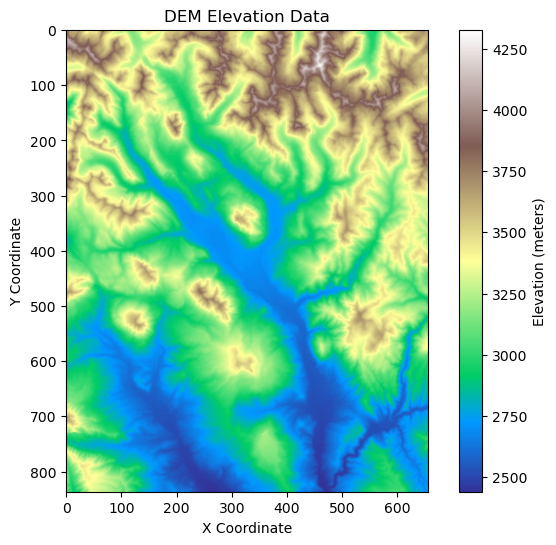

In [45]:
plt.figure(figsize=(8, 6))
plt.imshow(d, cmap='terrain', origin='upper')  # Use 'terrain' colormap for elevation
plt.colorbar(label='Elevation (meters)')  # Add color bar with a label
plt.title("DEM Elevation Data")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.show()

In [46]:
# do shade
from insolation import insolf

ModuleNotFoundError: No module named 'insolation'